<a href="https://colab.research.google.com/github/zaidkhan8241/Brain-Tumor-MRI-Prediction/blob/main/Brain_Tumor_MRI_using_transfer_learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset"
)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: zaid
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:08<00:00, 19.1MB/s]


In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential # Standardized import
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras.applications import EfficientNetB0

In [4]:
conv_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
conv_base.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [6]:
from tensorflow.keras import Sequential as KSequential # Standardized import, aliased to avoid conflict if `sequential` was used as variable
from keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
model = KSequential()
model.add(conv_base)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
        '/content/brain-tumor-mri-dataset/Training',
        target_size=(224, 224), # Changed to match EfficientNetB0 input
        batch_size=batch_size,
        class_mode='sparse') # Changed from 'binary' to 'sparse' for multi-class integer labels

validation_generator = test_datagen.flow_from_directory(
        '/content/brain-tumor-mri-dataset/Testing',
        target_size=(224, 224), # Changed to match EfficientNetB0 input
        batch_size=batch_size,
        class_mode='sparse') # Changed from 'binary' to 'sparse' for multi-class integer labels

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [8]:
conv_base.trainable = False

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 119s 499ms/step - accuracy: 0.6930 - loss: 0.8039 - val_accuracy: 0.7262 - val_loss: 0.7280
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 426ms/step - accuracy: 0.7948 - loss: 0.5433 - val_accuracy: 0.8206 - val_loss: 0.5438
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 409ms/step - accuracy: 0.8202 - loss: 0.4648 - val_accuracy: 0.8319 - val_loss: 0.5217
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 411ms/step - accuracy: 0.8446 - loss: 0.4196 - val_accuracy: 0.8200 - val_loss: 0.5123
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 401ms/step - accuracy: 0.8454 - loss: 0.4028 - val_accuracy: 0.7969 - val_loss: 0.5666
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 412ms/step - accuracy: 0.8516 - loss: 0.3771 - val_accuracy: 0.8475 - val_loss: 0.4255
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 408ms/step - accuracy: 0.8677 - loss: 0.3540 - val_accuracy: 0.8600 - val_loss: 0.4187
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 408ms/step - accuracy: 0.8673 - loss: 

In [22]:
conv_base.trainable = True

for layer in conv_base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 416ms/step - accuracy: 0.9859 - loss: 0.0491 - val_accuracy: 0.9456 - val_loss: 0.2507 - learning_rate: 1.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 421ms/step - accuracy: 0.9893 - loss: 0.0395 - val_accuracy: 0.9488 - val_loss: 0.2468 - learning_rate: 1.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 422ms/step - accuracy: 0.9882 - loss: 0.0409 - val_accuracy: 0.9469 - val_loss: 0.2661 - learning_rate: 1.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 430ms/step - accuracy: 0.9880 - loss: 0.0362 - val_accuracy: 0.9538 - val_loss: 0.2409 - learning_rate: 1.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 418ms/step - accuracy: 0.9887 - loss: 0.0338 - val_accuracy: 0.9531 - val_loss: 0.2468 - learning_rate: 1.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 425ms/step - accuracy: 0.9898 - loss: 0.0297 - val_accuracy: 0.9500 - val_loss: 0.2475 - learning_rate: 1.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 41

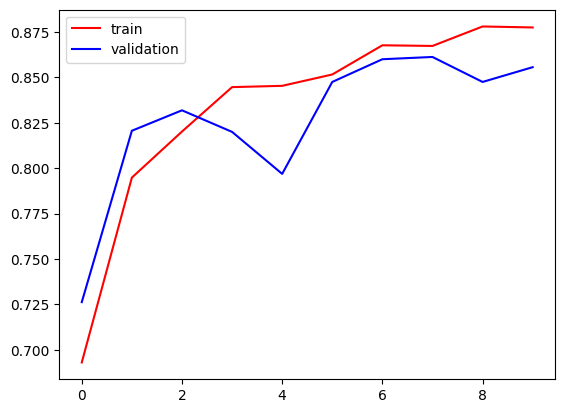

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

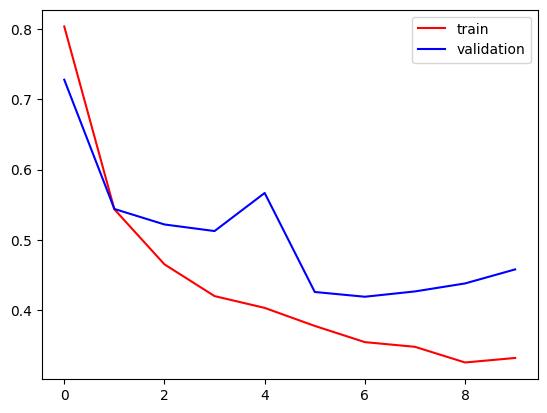

In [26]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [27]:
model.save('brain_tumor_classifier.keras')

In [28]:
import os

print(os.listdir())

['.config', 'class_indices.json', 'brain_tumor_classifier.keras', 'brain-tumor-mri-dataset', 'best_model.keras', 'sample_data']


In [29]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [30]:
class_indices = train_generator.class_indices

import json

with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# 1. Load the best model saved during training
loaded_model = load_model('best_model.keras')

# 2. Create an evaluation generator with shuffle=False
evaluation_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# 3. Get true labels (now perfectly aligned with the unshuffled generator)
true_labels = evaluation_generator.classes

# 4. Get predictions
print("Generating predictions...")
predictions = loaded_model.predict(evaluation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# 5. Calculate and print the Confusion Matrix
cm = confusion_matrix(true_labels, predicted_classes)
print("\nConfusion Matrix:")
print(cm)

# 6. Calculate and print the Classification Report
# Note: Ensure the order of target_names matches the generator's class indices
class_names = list(evaluation_generator.class_indices.keys())
report = classification_report(true_labels, predicted_classes, target_names=class_names)

print("\nClassification Report:")
print(report)

Found 1600 images belonging to 4 classes.
Generating predictions...
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step

Confusion Matrix:
[[330  39  29   2]
 [  2 396   0   2]
 [  0   0 400   0]
 [  0   0   0 400]]

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.82      0.90       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600

